In [1]:
import datetime
import textwrap

import dask.diagnostics
import faceted
import numpy as np
import pandas as pd
import xarray as xr

from upath import UPath

import plotting

In [2]:
ROOT = UPath("gs://vcm-ml-raw-flexible-retention/2025-08-22-C96-SHiELD/regridded-zarrs/gaussian_grid_180_by_360")
CLIMATES = ["1xCO2", "2xCO2", "4xCO2"]
ENSEMBLE_MEMBERS = ["ic_0001", "ic_0002", "ic_0003"]


def open_store(store):
    datasets = []
    for member in ENSEMBLE_MEMBERS:
        for climate in CLIMATES:
            if member == "ic_0001":
                path = ROOT / f"ramped-sst-{climate}-random-perturbation" / f"{store}.zarr"
            else:
                path = ROOT / f"ramped-sst-{climate}-random-perturbation-{member}" / f"{store}.zarr"
            ds = xr.open_zarr(str(path))
            ds = ds.assign_coords(member=member, climate=climate).expand_dims(["member", "climate"])
            datasets.append(ds)
    return xr.combine_by_coords(datasets)

In [3]:
full_state = open_store("full_state")
scalar = open_store("scalar")

In [4]:
interpolation_knots = {
    datetime.datetime(2019, 9, 15): 0.0,
    datetime.datetime(2020, 1, 1): 0.0,
    datetime.datetime(2021, 1, 1): 1.0,
    datetime.datetime(2022, 1, 1): 2.0,
    datetime.datetime(2023, 1, 1): 3.0,
    datetime.datetime(2024, 1, 1): 4.0,
    datetime.datetime(2025, 1, 1): 5.0,
    datetime.datetime(2026, 1, 1): 6.0,
}
offsets = xr.DataArray(list(interpolation_knots.values()), dims=["time"], coords=[list(interpolation_knots.keys())])
offsets = offsets.assign_coords(time=offsets.time.astype("datetime64[ns]"))

spinup = pd.DatetimeIndex(
    [
        datetime.datetime(2019, 9, 15),
        datetime.datetime(2019, 10, 15),
        datetime.datetime(2019, 11, 15),
        datetime.datetime(2019, 12, 15),
        datetime.datetime(2020, 1, 1),
    ]
)
ramp = xr.date_range("2020-01-01", periods=61, freq="MS") + pd.Timedelta(days=14)
target_times = spinup.append(ramp)
interpolated_offsets = offsets.interp(time=target_times)

In [5]:
MEMBER_LABELS = {
    "ic_0001": "Ens. 1",
    "ic_0002": "Ens. 2",
    "ic_0003": "Ens. 3",
}

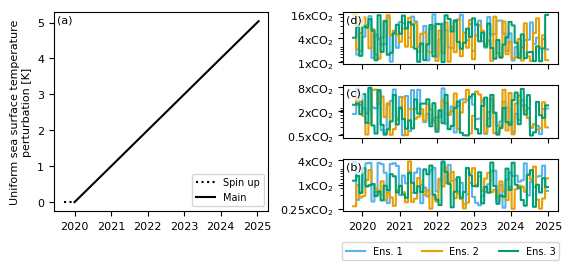

In [6]:
plotting.configure_style()

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# Figure: 6.5" wide; height so left panel has aspect ratio 0.618 (height/width)
width_ratios = [1, 1]  # left, right column
left_frac = width_ratios[0] / sum(width_ratios)
fig_width = 6.5
fig_height = 0.875 * fig_width * left_frac  # left panel height/width = 0.618
fig = plt.figure(figsize=(fig_width, fig_height))
# Add additional padding below the axes by increasing bottom margin with 'figure.subplots_adjust'
gs = GridSpec(3, 2, figure=fig, width_ratios=width_ratios, wspace=0.35, hspace=0.4)
fig.subplots_adjust(bottom=0.18)  # Set bottom margin (fraction of figure height)
# Left: single large axes (spans all rows) — aspect 0.618 by construction
ax_left = fig.add_subplot(gs[:, 0])
# Right: three axes stacked vertically
ax_right_bot = fig.add_subplot(gs[2, 1])
ax_right_mid = fig.add_subplot(gs[1, 1])
ax_right_top = fig.add_subplot(gs[0, 1])

for ax, climate in zip([ax_right_bot, ax_right_mid, ax_right_top], CLIMATES):
    for member in ["ic_0001", "ic_0002", "ic_0003"]:
        (1e6 * scalar.global_mean_co2).sel(member=member, climate=climate).plot(ax=ax, label=MEMBER_LABELS[member])

for ax in (ax_right_bot, ax_right_mid, ax_right_top):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.set_yscale("log")

for ax in (ax_right_mid, ax_right_top):
    ax.set_xticklabels([])

interpolated_offsets.sel(time=slice("2019")).plot(ax=ax_left, color="k", linestyle=":", label="Spin up")
interpolated_offsets.sel(time=slice("2020", None)).plot(ax=ax_left, color="k", label="Main")
ax_left.set_xlabel("")
ax_left.set_ylabel(textwrap.fill("Uniform sea surface temperature perturbation [K]", width=40))
ax_left.legend(loc="lower right", fontsize=7)

ax_right_bot.set_yticks([0.25 * 363.43, 363.43, 4 * 363.43])
ax_right_bot.set_yticklabels(["0.25xCO$_2$", "1xCO$_2$", "4xCO$_2$"])

ax_right_mid.set_yticks([0.5 * 363.43, 2 * 363.43, 8 * 363.43])
ax_right_mid.set_yticklabels(["0.5xCO$_2$", "2xCO$_2$", "8xCO$_2$"])

ax_right_top.set_yticks([363.43, 4 * 363.43, 16 * 363.43])
ax_right_top.set_yticklabels(["1xCO$_2$", "4xCO$_2$", "16xCO$_2$"])

ax_right_bot.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.5),
    ncol=3,
    fontsize=7
)

for ax, label in zip((ax_left, ax_right_bot, ax_right_mid, ax_right_top), ("a", "b", "c", "d")):
    # To ensure axes lines and ticks are above the annotation label,
    # we set zorder for the label's bbox and then raise axes elements.
    # Also, redraw ticks and spines after annotation if needed.
    ann = ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        zorder=2,  # lower than axes lines and ticks (default for spines/ticks is usually higher)
    )
    # Ensure that axes spines and ticks are above the annotation
    for spine in ax.spines.values():
        spine.set_zorder(3)
    for tick in ax.xaxis.get_major_ticks() + ax.yaxis.get_major_ticks():
        tick.tick1line.set_zorder(3)
        tick.tick2line.set_zorder(3)
        tick.gridline.set_zorder(2.5)
        tick.label1.set_zorder(4)
        tick.label2.set_zorder(4)

fig.subplots_adjust(wspace=0.25)
fig.patch.set_alpha(0.0)
fig.savefig("figure-01.png", dpi=300)
fig.savefig("figure-01.pdf")